# ROGII EDA

Quick schema, missing-value, and Prediction Start inspection.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'src'))
from dataset import list_well_ids, load_well

DATA_DIR = ROOT / 'data'
train_ids = list_well_ids(DATA_DIR, 'train')
test_ids = list_well_ids(DATA_DIR, 'test')
len(train_ids), len(test_ids), test_ids

(773, 3, ['000d7d20', '00bbac68', '00e12e8b'])

In [2]:
rows = []
for well_id in train_ids:
    well = load_well(DATA_DIR, 'train', well_id)
    h = well.horizontal
    first_missing = h.index[h['TVT_input'].isna()].min()
    rows.append({
        'well_id': well_id,
        'rows': len(h),
        'first_missing_tvt_input': first_missing,
        'missing_tvt_input': h['TVT_input'].isna().sum(),
        'missing_gr': h['GR'].isna().sum(),
    })
summary = pd.DataFrame(rows)
summary.describe(include='all')

,well_id,rows,first_missing_tvt_input,missing_tvt_input,missing_gr
count,773,773.000000,773.000000,773.000000,773.000000
unique,773,NaN,NaN,NaN,NaN
top,000d7d20,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN
mean,NaN,6587.652005,1692.452781,4895.199224,1950.804657
std,NaN,1311.463547,217.343826,1301.178409,1391.022492
min,NaN,2058.000000,851.000000,407.000000,42.000000
25%,NaN,5706.000000,1546.000000,4044.000000,767.000000
50%,NaN,6576.000000,1703.000000,4840.000000,1754.000000
75%,NaN,7388.000000,1839.000000,5694.000000,2992.000000


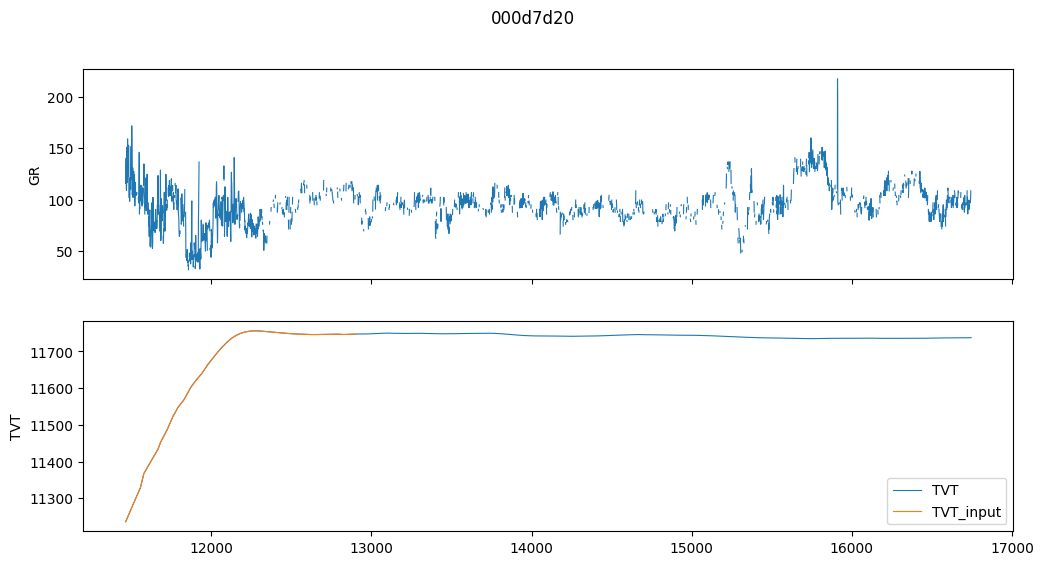

In [3]:
well = load_well(DATA_DIR, 'train', train_ids[0])
h = well.horizontal
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(h['MD'], h['GR'], lw=0.8)
axes[0].set_ylabel('GR')
axes[1].plot(h['MD'], h['TVT'], label='TVT', lw=0.8)
axes[1].plot(h['MD'], h['TVT_input'], label='TVT_input', lw=0.8)
axes[1].set_ylabel('TVT')
axes[1].legend()
fig.suptitle(well.well_id)
plt.show()